# Name : Swaraj Patil

# TY-CSAI-B

# Roll No : 07

# PRN : 12310234


#Assignment 9
Implementation of RNN model for Stock Price Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [3]:
data = pd.read_csv('stock_prices.csv')
data = data[['Close']]

In [4]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [5]:
X = []
y = []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape for RNN
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [6]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [7]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(LSTM(units=50))

model.add(Dense(1))  # output layer

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0391
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0101
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0062
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0047
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0044
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0041
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0040
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0040
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0038
Epoch 10/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0037


In [9]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 414ms/step


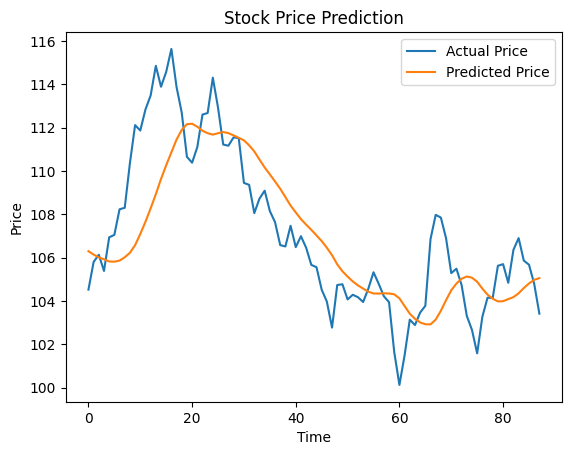

In [10]:
actual = scaler.inverse_transform(y_test.reshape(-1,1))

plt.plot(actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price')

plt.title("Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.show()

In [11]:
pip install yfinance

In [12]:
import yfinance as yf
import pandas as pd

# Example: Apple stock
df = yf.download('AAPL', start='2018-01-01', end='2024-01-01')

# Save dataset
df.to_csv("real_stock_data.csv")

print(df.head())

/tmp/ipykernel_7602/748830199.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2018-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2018-01-02  40.304173  40.313533  39.602254  39.812832  102223600
2018-01-03  40.297153  40.839972  40.233983  40.367346  118071600
2018-01-04  40.484341  40.587289  40.262067  40.369693   89738400
2018-01-05  40.945263  41.031832  40.489016  40.580266   94640000
2018-01-08  40.793186  41.087991  40.694914  40.793186   82271200


In [13]:
from sklearn.preprocessing import MinMaxScaler

data = df[['Open','High','Low','Close','Volume']]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [14]:
X, y = [], []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i, 3])  # Close price

X, y = np.array(X), np.array(y)

In [15]:
from tensorflow.keras.layers import Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
history = model.fit(X, y, epochs=20, batch_size=32)

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - loss: 0.0196
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0038
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0031
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0029
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0025
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0023
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0023
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.0021
Epoch 9/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0023
Epoch 10/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0022
Epoch 11/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0019
Epoch 12/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0018
Epoch 13/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0019
Epoch 14/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0018
Epoch 15/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.0019
Epo

46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step


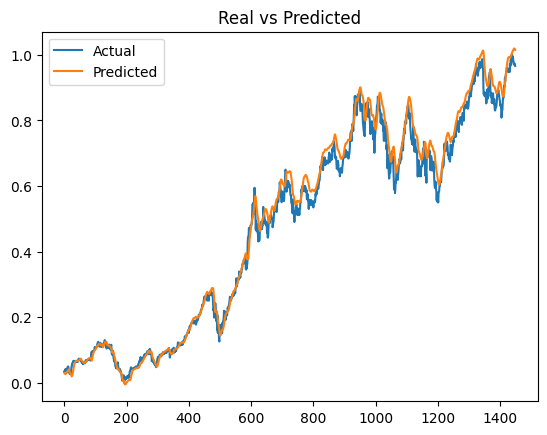

In [17]:
pred = model.predict(X)
plt.plot(y, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.title("Real vs Predicted")
plt.show()

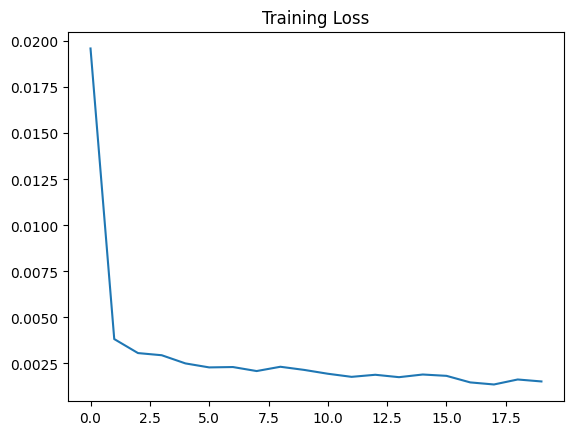

In [18]:
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.show()

In [19]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y, pred))
print("RMSE:", rmse)

RMSE: 0.033851610011195264
